In [23]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import datetime

import warnings
warnings.filterwarnings("ignore")

In [73]:
'''
d4pdf daily to 95th percentile
'''

for scen in ['HPB','HPB_NAT']:
    print(scen)
    for num in range(1,101):
        num_string = '0' + str(num) if num > 9 else '00' + str(num)
        if num == 100:
            num_string = '100'

        print(num_string)

        day_FWI = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/daily/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+num_string+'.nc')

        d4pdf_percentile = day_FWI.groupby('time.year').quantile(0.95,dim='time')
        d4pdf_percentile.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_m'+num_string+'.nc')

        break
    break


HPB
001


/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1392: RuntimeWarning: All-NaN slice encountered
  overwrite_input, interpolation)


In [8]:
'''
cam5 daily to 95th percentile
'''
ens_list_dict = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                 'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}

for scen in ['All','Nat']:
    print(scen)
    for num in ens_list_dict[scen]:
        num_string = '0' + str(num) if num > 9 else '00' + str(num)
        if num == 100:
            num_string = '100'

        print(num_string)

        day_FWI = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/FWI_'+scen+'_run'+num_string+'.nc')

        cam5_percentile = day_FWI.groupby('time.year').quantile(0.95,dim='time')
        cam5_percentile['year'] = [datetime.datetime(year, 1, 1) for year in cam5_percentile.year]
        cam5_percentile = cam5_percentile.rename({'year':'time'})
        
        cam5_percentile.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_'+scen+'_run'+num_string+'.nc')



All
001
002
003
004
005
006
007
008
009
010
036
037
038
039
040
041
042
043
061
062
063
064
065
066
067
068
069
070
086
087
088
089
090
091
092
093
094
095
096
097
098
099
100
Nat
001
002
003
004
005
006
007
008
009
010
036
037
038
039
040
041
042
043
044
045
046
047
048
049
050
061
062
063
064
065
066
067
068
069
070
086
087
088
089
090
091
092
093
094
095
097
098
099
100


In [19]:
'''
ERA5 daily to 95th percentile @ ERA5, d4pdf, and cam5 resolutions
'''
# ERA5 land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/static/land_sea_mask.nc')
lsm = lsm.isel(time=0).drop('time')

# example d4pdf and cam5
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/daily/BC_wind_FWI/BC_wind_FWI_HPB_m001.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/FWI_All_run001.nc')

era5_daily = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/ERA5_FWI_1951-2021.nc')
era5_daily['longitude'] = [lon + 360 for lon in era5_daily.longitude.data]

era5_daily = era5_daily.where(lsm.lsm>0)
era5_percentile = era5_daily.groupby('time.year').quantile(0.95,dim='time')
era5_percentile['year'] = [datetime.datetime(year, 1, 1) for year in era5_percentile.year]
era5_percentile = era5_percentile.rename({'year':'time'})

# ERA5 resolution
era5_percentile.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/ERA5_FWI_95p_ERA5_resolution.nc')

# d4PDF resoltuion
era5_percentile_d4pdf = era5_percentile.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_percentile_d4pdf = era5_percentile_d4pdf.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
era5_percentile_d4pdf.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')

# CAM5 resolution
era5_percentile_cam5 = era5_percentile.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_percentile_cam5 = era5_percentile_cam5.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
era5_percentile_cam5.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')




In [50]:
era5_percentile_d4pdf

<xarray.DataArray (time: 71, latitude: 92, longitude: 59)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
         39.7076773 , 52.63006116],
        [        nan,         nan,         nan, ..., 26.85666359,
         36.09903542, 53.23990303],
        ...,
        [        nan,         nan,         nan, ..., 18.41103784,
         19.78619705, 20.69685618],
        [        nan,         nan,         nan, ..., 19.88823605,
         19.43524076, 18.03918759],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
         41.69149027, 55.23204728],
        [        nan,         nan,         nan, ..., 30.87140803,
         37.10754047, 54.60978953],
...
        [        nan,         nan,         nan, ..., 10.44879271,
         11.40901266, 12.48676481],
        [        nan,         nan,         nan, ..., 11.33325332,
         11.83345774, 10.88442999],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
         33.36308908, 45.51854311],
        [        nan,         nan,         nan, ..., 26.490946  ,
         29.90123035, 45.35478119],
        ...,
        [        nan,         nan,         nan, ...,  6.66597818,
          6.7731747 ,  6.8026196 ],
        [        nan,         nan,         nan, ...,  6.85028379,
          6.83010324,  5.76387406],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
    quantile   float64 0.95
  * time       (time) datetime64[ns] 1951-01-01 1952-01-01 ... 2021-01-01
  * longitude  (longitude) float64 222.8 223.3 223.9 224.4 ... 254.2 254.8 255.4
  * latitude   (latitude) float64 19.94 20.5 21.06 21.62 ... 69.92 70.48 71.05

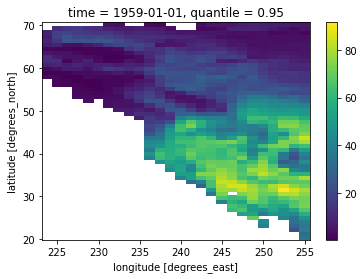

In [47]:
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')
cam5 = cam5.sel(time=slice('1959','2018'))
da = era5_percentile_cam5.where(~cam5.isnull())
da.isel(time=0).plot()

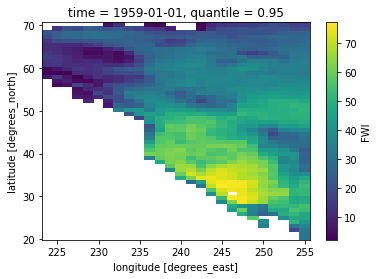

In [49]:
cam5.where(~da.isnull()).isel(time=0).plot()

In [36]:
cam5.time

<xarray.DataArray 'time' (time: 60)>
array(['1959-12-31T00:00:00.000000000', '1960-12-31T00:00:00.000000000',
       '1961-12-31T00:00:00.000000000', '1962-12-31T00:00:00.000000000',
       '1963-12-31T00:00:00.000000000', '1964-12-31T00:00:00.000000000',
       '1965-12-31T00:00:00.000000000', '1966-12-31T00:00:00.000000000',
       '1967-12-31T00:00:00.000000000', '1968-12-31T00:00:00.000000000',
       '1969-12-31T00:00:00.000000000', '1970-12-31T00:00:00.000000000',
       '1971-12-31T00:00:00.000000000', '1972-12-31T00:00:00.000000000',
       '1973-12-31T00:00:00.000000000', '1974-12-31T00:00:00.000000000',
       '1975-12-31T00:00:00.000000000', '1976-12-31T00:00:00.000000000',
       '1977-12-31T00:00:00.000000000', '1978-12-31T00:00:00.000000000',
       '1979-12-31T00:00:00.000000000', '1980-12-31T00:00:00.000000000',
       '1981-12-31T00:00:00.000000000', '1982-12-31T00:00:00.000000000',
       '1983-12-31T00:00:00.000000000', '1984-12-31T00:00:00.000000000',
       '1985-12-31T00:00:00.000000000', '1986-12-31T00:00:00.000000000',
       '1987-12-31T00:00:00.000000000', '1988-12-31T00:00:00.000000000',
       '1989-12-31T00:00:00.000000000', '1990-12-31T00:00:00.000000000',
       '1991-12-31T00:00:00.000000000', '1992-12-31T00:00:00.000000000',
       '1993-12-31T00:00:00.000000000', '1994-12-31T00:00:00.000000000',
       '1995-12-31T00:00:00.000000000', '1996-12-31T00:00:00.000000000',
       '1997-12-31T00:00:00.000000000', '1998-12-31T00:00:00.000000000',
       '1999-12-31T00:00:00.000000000', '2000-12-31T00:00:00.000000000',
       '2001-12-31T00:00:00.000000000', '2002-12-31T00:00:00.000000000',
       '2003-12-31T00:00:00.000000000', '2004-12-31T00:00:00.000000000',
       '2005-12-31T00:00:00.000000000', '2006-12-31T00:00:00.000000000',
       '2007-12-31T00:00:00.000000000', '2008-12-31T00:00:00.000000000',
       '2009-12-31T00:00:00.000000000', '2010-12-31T00:00:00.000000000',
       '2011-12-31T00:00:00.000000000', '2012-12-31T00:00:00.000000000',
       '2013-12-31T00:00:00.000000000', '2014-12-31T00:00:00.000000000',
       '2015-12-31T00:00:00.000000000', '2016-12-31T00:00:00.000000000',
       '2017-12-31T00:00:00.000000000', '2018-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1959-12-31 1960-12-31 ... 2018-12-31
Attributes:
    standard_name:  time
    axis:           T

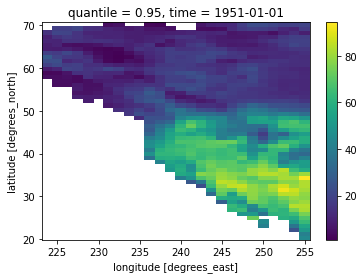

In [29]:
# CAM5 resolution
era5_percentile_cam5 = era5_percentile.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_percentile_cam5 = era5_percentile_cam5.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
#era5_percentile_cam5.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')

era5_percentile_cam5.isel(time=0).plot()

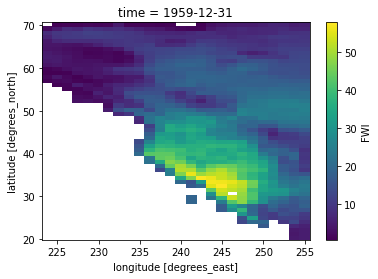

In [26]:
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
cam5.isel(time=0).plot()

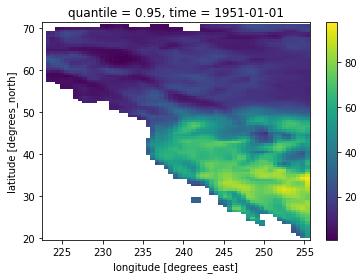

In [30]:
era5_percentile_d4pdf = era5_percentile.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_percentile_d4pdf = era5_percentile_d4pdf.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")

era5_percentile_d4pdf.isel(time=0).plot()

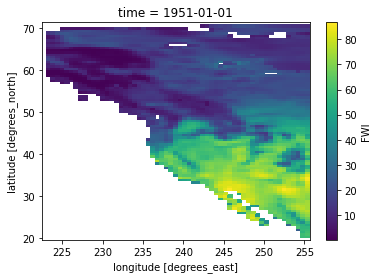

In [31]:
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
d4pdf.isel(time=0).plot()

In [17]:
# d4PDF resoltuion
era5_percentile_d4pdf = era5_percentile.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_percentile_d4pdf = era5_percentile_d4pdf.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
era5_percentile_d4pdf.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')

# CAM5 resolution
era5_percentile_cam5 = era5_percentile.coarsen(latitude=2,longitude=2,boundary='pad').mean()
era5_percentile_cam5 = era5_percentile_cam5.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
era5_percentile_cam5.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')


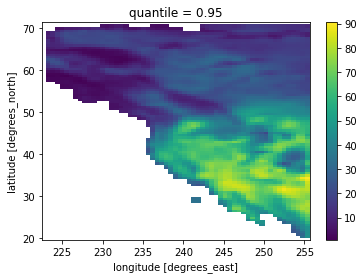

In [69]:
era5_percentile_cam5.mean('year').plot()

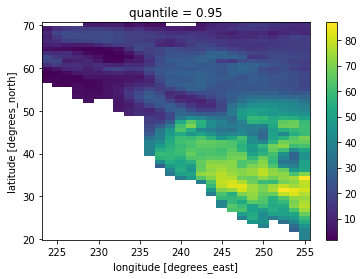

In [70]:
era5_percentile_cam5.mean('year').plot()

In [9]:
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')

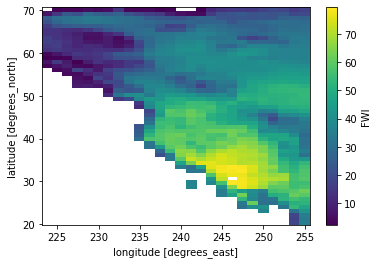

In [12]:
da.mean('time').plot()